# Rep 3. Checkpoint 2. Black Scholes y Volatility surface

In [4]:
import numpy as np
import pandas as pd
import yfinance as yf
from datetime import date
from scipy.stats import norm
from scipy.optimize import brentq, newton
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')


# Black-Scholes
def bs_price(S, K, r, T, sigma, option="call"):
    if sigma <= 0 or T <= 0:
        # Límite: precio intrínseco descontado
        if option == "call":
            return max(0.0, S - K*np.exp(-r*T))
        else:
            return max(0.0, K*np.exp(-r*T) - S)
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    if option.lower() == "call":
        return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    else:
        return K*np.exp(-r*T)*norm.cdf(-d2) - S*norm.cdf(-d1)

def bs_vega(S, K, r, T, sigma):
    if sigma <= 0 or T <= 0:
        return 0.0
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    return S * norm.pdf(d1) * np.sqrt(T)  # en unidades de precio por 1.0 de sigma


def implied_vol(price_mkt, S, K, r, T, option="call", brent_bounds=(1e-6, 5.0), tol=1e-8, maxiter=100):

    # Verificación de límites teóricos: el precio debe estar entre [intrínseco, cota superior]
    if option == "call":
        lower = max(0.0, S - K*np.exp(-r*T))
        upper = S
    else:
        lower = max(0.0, K*np.exp(-r*T) - S)
        upper = K*np.exp(-r*T)

    if not (lower - 1e-12 <= price_mkt <= upper + 1e-12):
        raise ValueError(f"Precio de mercado fuera de rango teórico [{lower:.4f}, {upper:.4f}]")

    # Función objetivo
    def f(sig):
        return bs_price(S, K, r, T, sig, option) - price_mkt

    a, b = brent_bounds
    fa, fb = f(a), f(b)

    # Ajusta el extremo superior si no cambia de signo (intenta ampliar)
    if fa*fb > 0:
        # intenta expandir b
        for b_try in [10.0, 15.0, 25.0, 50.0]:
            fb = f(b_try)
            if fa*fb <= 0:
                b = b_try
                break

    # Intenta Brent
    try:
        iv = brentq(f, a, b, xtol=tol, maxiter=maxiter)
        return iv
    except Exception:
        pass

    # Si Brent falla, intenta método de Newton
    seed = min(max(sigma_hist if 'sigma_hist' in globals() and np.isfinite(sigma_hist) else 0.2, 1e-3), 2.0)
    try:
        iv = newton(lambda s: f(s), seed, fprime=lambda s: bs_vega(S, K, r, T, s), tol=tol, maxiter=maxiter)
        if iv > 0:
            return iv5
    except Exception:
        pass

    raise RuntimeError("No se pudo encontrar una volatilidad implícita con los métodos intentados.")


## Actividad

--- Análisis de Volatilidad Implícita (Ticker: SPY | Vencimiento: 2026-04-17) ---


,Strike,Bid,Ask,Mid,IV (%)
4,655.0,19.64,19.86,19.750,9.938102
5,663.0,14.61,14.66,14.635,11.405049
6,671.0,10.10,10.16,10.130,11.802067
7,680.0,5.95,6.00,5.975,11.664505
8,688.0,3.25,3.29,3.270,11.297375
9,696.0,1.54,1.57,1.555,10.909269
10,704.0,0.64,0.67,0.655,10.640116
11,712.0,0.27,0.29,0.280,10.705018
12,720.0,0.13,0.15,0.140,11.140737
13,728.0,0.08,0.09,0.085,11.852198


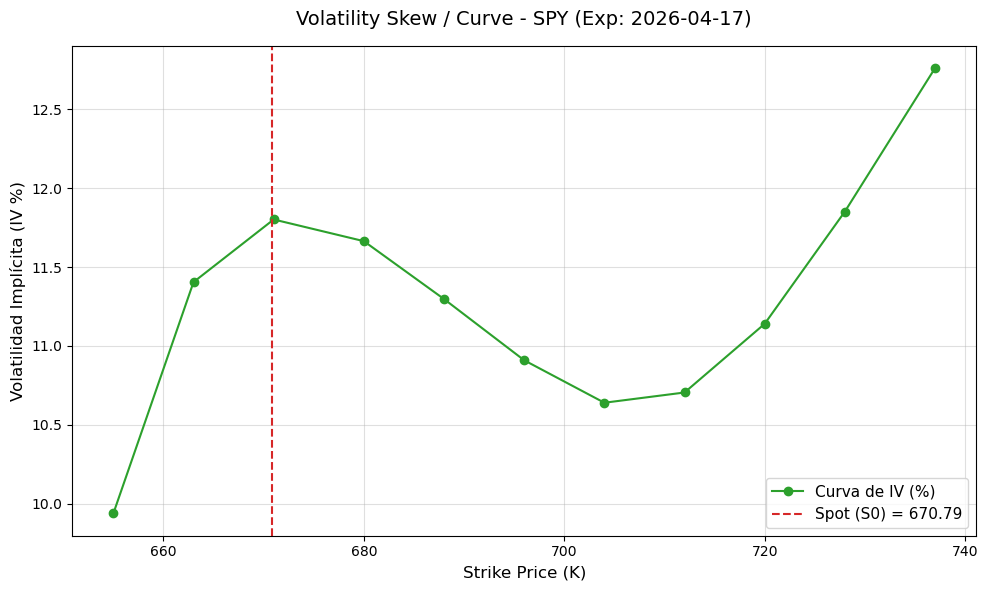

In [6]:
# Parámetros iniciales
ticker = 'SPY'
tk = yf.Ticker(ticker)
exp = '2026-04-17'
r = 0.042  # Tasa libre de riesgo asumida en clase
today = date.today()
T = (date.fromisoformat(exp) - today).days / 365.0

# 1. Obtener el precio spot (S0) dinámicamente
data = yf.download(ticker, start='2026-01-01', end=today, progress=False)['Close']
S0 = float(data.iloc[-1])

# 2. Obtener la cadena de opciones
chain = tk.option_chain(exp).calls

# 3. Filtrar strikes para el rango [S0 * 0.88, S0 * 1.10]
lower_bound = S0 * 0.88
upper_bound = S0 * 1.10
chain_filtered = chain[(chain['strike'] >= lower_bound) & (chain['strike'] <= upper_bound)].copy()

# Si hay demasiados strikes, podemos tomar una muestra uniforme de ~15 strikes para claridad en la tabla
if len(chain_filtered) > 15:
    indices = np.linspace(0, len(chain_filtered) - 1, 15).astype(int)
    chain_filtered = chain_filtered.iloc[indices]

results = []

# 4. Calcular el precio Mid y la IV para cada strike
for index, row in chain_filtered.iterrows():
    K = row['strike']
    bid = row['bid']
    ask = row['ask']
    mid = (bid + ask) / 2.0
    
    # Manejo de errores por si la función no converge
    try:
        iv = implied_vol(mid, S0, K, r, T, option="call")
    except Exception as e:
        iv = np.nan
        
    results.append({
        'Strike': K,
        'Bid': bid,
        'Ask': ask,
        'Mid': mid,
        'IV (%)': iv * 100 if not np.isnan(iv) else np.nan
    })

# Crear DataFrame y limpiar valores que no convergieron
df_results = pd.DataFrame(results).dropna()

# 5. Imprimir la tabla como output (el método display genera una tabla HTML nativa en Jupyter)
print(f"--- Análisis de Volatilidad Implícita (Ticker: {ticker} | Vencimiento: {exp}) ---")
display(df_results)

# 6. Generar la gráfica de IV vs Strike
plt.figure(figsize=(10, 6))
plt.plot(df_results['Strike'], df_results['IV (%)'], marker='o', linestyle='-', color='#2ca02c', label='Curva de IV (%)')

# Línea vertical para el precio Spot ATM
plt.axvline(x=S0, color='#d62728', linestyle='--', label=f'Spot (S0) = {S0:.2f}')

# Formato, títulos y etiquetas
plt.title(f'Volatility Skew / Curve - {ticker} (Exp: {exp})', fontsize=14, pad=15)
plt.xlabel('Strike Price (K)', fontsize=12)
plt.ylabel('Volatilidad Implícita (IV %)', fontsize=12)
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.4)
plt.tight_layout()

# Mostrar gráfico
plt.show()

### Análisis de Resultados: Volatility Skew

**1. ¿La curva de IV es decreciente, creciente o tiene forma de smile? ¿Qué implica eso?**

En nuestra gráfica, la curva muestra una forma de smile irregular. La volatilidad implícita tiene una caída abrupta en los strikes bajos (ej. strike 655), luego sube alrededor del precio spot ($S_0$), desciende hasta formar un "valle" y vuelve a subir en los strikes más altos (ej. strike 737). 

**2. ¿En qué strike es mínima la IV? ¿Coincide con S0?**

Según la tabla, la IV alcanza su punto mínimo en el **strike 655.0**, con un valor de **9.94%**. 

**3. ¿Qué estarían comprando los inversores que pagan una IV alta en strikes bajos?**

Los inversores que pagan volatilidades implícitas altas en strikes muy por debajo del spot están comprando **cobertura o seguros (protective puts)**. Están dispuestos a pagar una prima excesiva por el miedo a que el mercado sufra una caída brusca o un *crash*.

**4. ¿Qué le diría esta curva a alguien que quiere usar Black–Scholes con una sola volatilidad constante?**

La curva demuestra que el mercado no usa una volatilidad constante; en nuestra tabla, la IV fluctúa desde un 6.42% hasta un 12.76% dependiendo del strike. Si alguien usa una única volatilidad (por ejemplo, asumiendo la IV ATM de ~11.28% para todo), sobreestimará el valor de las opciones en el valle (strike 709) y subestimará severamente las opciones en los extremos.